In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup successful!")
print("Pandas version:", pd.__version__)

Setup successful!
Pandas version: 2.2.3


In [35]:
!wget -q --show-progress "https://media.githubusercontent.com/media/StackExchange/Survey/refs/heads/main/packages/archive/2025/results.csv" -O results.csv

results.csv         100%[===================>] 134.37M   354MB/s    in 0.4s    


In [36]:
!ls -lh results.csv


-rw-r--r-- 1 root root 135M Aug 19 08:01 results.csv


In [37]:
columns = pd.read_csv("results.csv", nrows=0).columns

[
    column
    for column in columns
    if "year" in column.lower()
    or "exp" in column.lower()
    or "work" in column.lower()
]

['WorkExp',
 'YearsCode',
 'RemoteWork',
 'ToolCountWork',
 'LanguageHaveWorkedWith',
 'LanguageWantToWorkWith',
 'DatabaseHaveWorkedWith',
 'DatabaseWantToWorkWith',
 'PlatformHaveWorkedWith',
 'PlatformWantToWorkWith',
 'WebframeHaveWorkedWith',
 'WebframeWantToWorkWith',
 'DevEnvsHaveWorkedWith',
 'DevEnvsWantToWorkWith',
 'SOTagsHaveWorkedWith',
 'SOTagsWantToWorkWith',
 'OfficeStackAsyncHaveWorkedWith',
 'OfficeStackAsyncWantToWorkWith',
 'CommPlatformHaveWorkedWith',
 'CommPlatformWantToWorkWith',
 'AIModelsHaveWorkedWith',
 'AIModelsWantToWorkWith',
 'AIExplain',
 'ConvertedCompYearly']

In [38]:
df = pd.read_csv(
    "results.csv",
    usecols=["RemoteWork", "JobSat", "WorkExp", "Age"]
)

print("Rows and columns:", df.shape)
df.head()

Rows and columns: (49191, 4)


,Age,WorkExp,RemoteWork,JobSat
0,25-34 years old,8.0,Remote,10.0
1,25-34 years old,2.0,"Hybrid (some in-person, leans heavy to flexibi...",9.0
2,35-44 years old,10.0,NaN,8.0
3,35-44 years old,4.0,Remote,6.0
4,35-44 years old,21.0,NaN,7.0


In [39]:
df.info()

print("\nMissing values:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         49191 non-null  object 
 1   WorkExp     42893 non-null  float64
 2   RemoteWork  33780 non-null  object 
 3   JobSat      26670 non-null  float64
dtypes: float64(2), object(2)
memory usage: 1.5+ MB

Missing values:
Age               0
WorkExp        6298
RemoteWork    15411
JobSat        22521
dtype: int64


In [40]:
print("Remote-work answers:")
print(df["RemoteWork"].value_counts(dropna=False))

print("\nJob-satisfaction summary:")
print(df["JobSat"].describe())

Remote-work answers:
RemoteWork
NaN                                                                             15411
Remote                                                                          10931
Hybrid (some remote, leans heavy to in-person)                                   6732
In-person                                                                        6042
Hybrid (some in-person, leans heavy to flexibility)                              5831
Your choice (very flexible, you can come in when you want or just as needed)     4244
Name: count, dtype: int64

Job-satisfaction summary:
count    26670.000000
mean         7.201950
std          1.997245
min          0.000000
25%          6.000000
50%          8.000000
75%          8.000000
max         10.000000
Name: JobSat, dtype: float64


In [41]:
clean_df = df.dropna(
    subset=["RemoteWork", "JobSat"]
).copy()

print(clean_df.shape)

(22797, 4)


In [42]:
summary = (
    clean_df.groupby("RemoteWork")["JobSat"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("mean", ascending=False)
)

summary

,count,mean,median
RemoteWork,,,
"Your choice (very flexible, you can come in when you want or just as needed)",2848,7.43,8.0
Remote,7908,7.32,8.0
"Hybrid (some in-person, leans heavy to flexibility)",4046,7.21,8.0
"Hybrid (some remote, leans heavy to in-person)",4499,7.08,7.0
In-person,3496,6.99,7.0


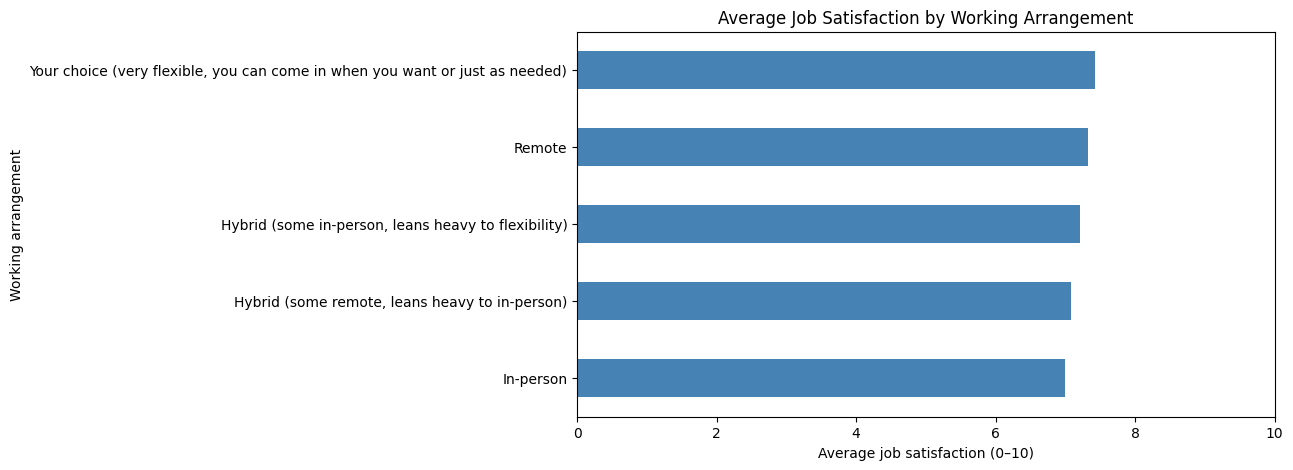

In [43]:
summary["mean"].sort_values().plot(
    kind="barh",
    figsize=(9, 5),
    color="steelblue"
)

plt.title("Average Job Satisfaction by Working Arrangement")
plt.xlabel("Average job satisfaction (0–10)")
plt.ylabel("Working arrangement")
plt.xlim(0, 10)
plt.show()

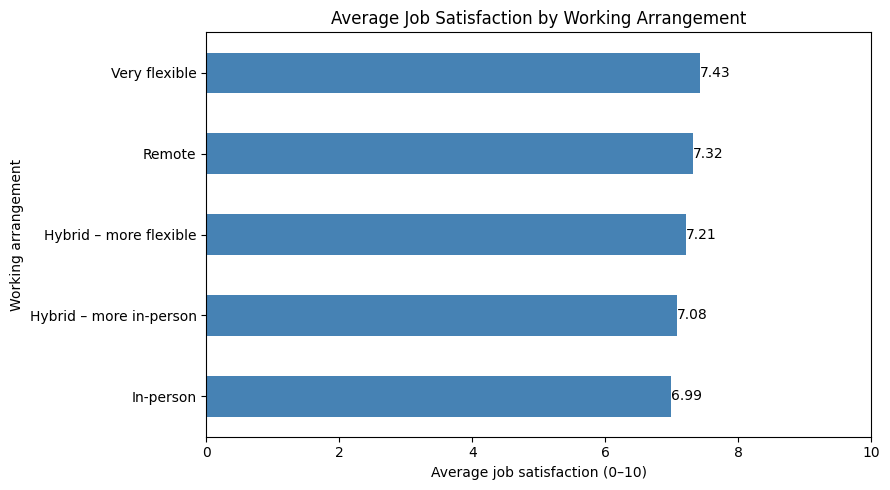

In [44]:
short_names = {
    "Your choice (very flexible, you can come in when you want or just as needed)": "Very flexible",
    "Remote": "Remote",
    "Hybrid (some in-person, leans heavy to flexibility)": "Hybrid – more flexible",
    "Hybrid (some remote, leans heavy to in-person)": "Hybrid – more in-person",
    "In-person": "In-person"
}

chart_data = summary.copy()
chart_data.index = chart_data.index.map(short_names)

ax = chart_data["mean"].sort_values().plot(
    kind="barh",
    figsize=(9, 5),
    color="steelblue"
)

ax.bar_label(ax.containers[0], fmt="%.2f")

plt.title("Average Job Satisfaction by Working Arrangement")
plt.xlabel("Average job satisfaction (0–10)")
plt.ylabel("Working arrangement")
plt.xlim(0, 10)
plt.tight_layout()

plt.savefig(
    "job_satisfaction_work_arrangement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Finding 1: Work flexibility and job satisfaction

Among survey respondents, average job satisfaction increased as working arrangements became more flexible. Respondents with very flexible arrangements reported the highest average satisfaction (7.43), while in-person respondents reported the lowest (6.99). However, the difference was small— 0.44 points on a 0–10 scale. These results suggest an association between flexibility and job satisfaction, but they do not prove that flexibility causes higher satisfaction.

In [45]:
experience_df = clean_df.dropna(
    subset=["WorkExp"]
).copy()

print(experience_df.shape)
print(experience_df["WorkExp"].describe())

(22407, 4)
count    22407.000000
mean        12.965368
std          9.594550
min          1.000000
25%          5.000000
50%         10.000000
75%         19.000000
max        100.000000
Name: WorkExp, dtype: float64


In [46]:
experience_df.loc[
    experience_df["WorkExp"] > 60,
    ["Age", "WorkExp"]
].sort_values("WorkExp", ascending=False)

,Age,WorkExp
21455,35-44 years old,100.0
28570,18-24 years old,100.0
36624,55-64 years old,100.0
2520,65 years or older,65.0


In [47]:
experience_df = experience_df[
    experience_df["WorkExp"] <= 65
].copy()

print(experience_df.shape)


(22404, 4)


In [48]:
experience_df["ExperienceGroup"] = pd.cut(
    experience_df["WorkExp"],
    bins=[0, 5, 10, 20, float("inf")],
    labels=["1–4 years", "5–9 years", "10–19 years", "20+ years"],
    right=False
)

print(experience_df["ExperienceGroup"].value_counts().sort_index())

ExperienceGroup
1–4 years      4528
5–9 years      5239
10–19 years    7302
20+ years      5335
Name: count, dtype: int64


In [49]:
experience_df["WorkType"] = experience_df["RemoteWork"].map(short_names)

experience_summary = experience_df.pivot_table(
    index="ExperienceGroup",
    columns="WorkType",
    values="JobSat",
    aggfunc="mean",
    observed=False
).round(2)

experience_summary

WorkType,Hybrid – more flexible,Hybrid – more in-person,In-person,Remote,Very flexible
ExperienceGroup,,,,,
1–4 years,7.07,6.93,6.73,7.05,7.29
5–9 years,7.19,7.03,6.95,7.18,7.40
10–19 years,7.21,7.07,7.16,7.37,7.39
20+ years,7.32,7.35,7.37,7.52,7.63


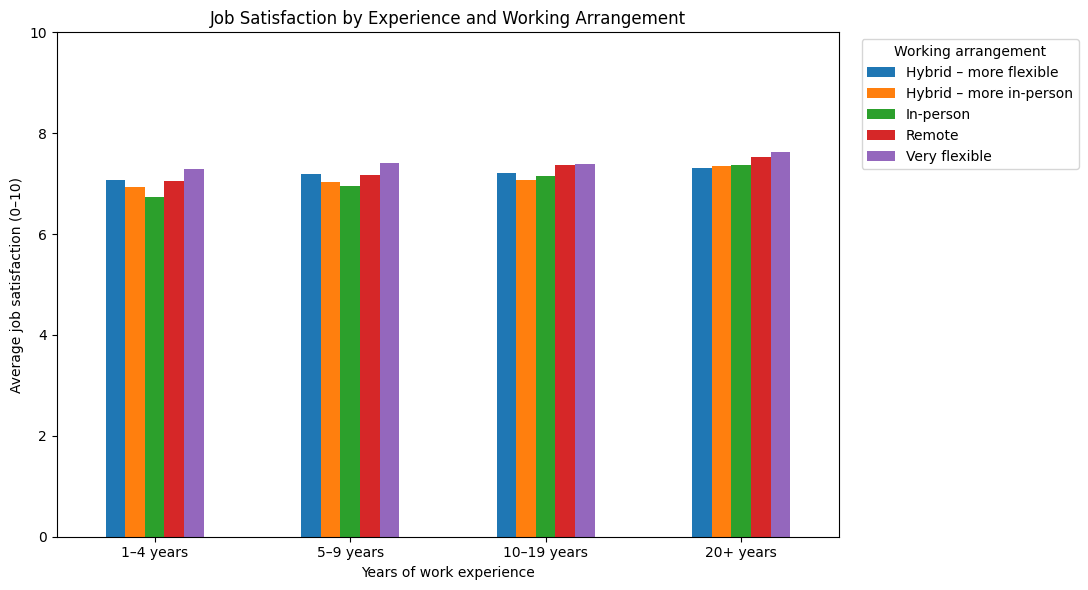

In [50]:
experience_summary.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Job Satisfaction by Experience and Working Arrangement")
plt.xlabel("Years of work experience")
plt.ylabel("Average job satisfaction (0–10)")
plt.ylim(0, 10)
plt.xticks(rotation=0)

plt.legend(
    title="Working arrangement",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(
    "job_satisfaction_experience.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Finding 2: Work experience and job satisfaction

Although the differences were small, average job satisfaction increased with years of work experience across every working arrangement. Very flexible work consistently had the highest average satisfaction. The lowest value was 6.73 among in-person respondents with 1–4 years of experience, while the highest was 7.63 among very flexible respondents with 20 or more years of experience.


In [51]:
print(clean_df["Age"].value_counts())

Age
25-34 years old      8572
35-44 years old      7052
45-54 years old      3118
18-24 years old      2678
55-64 years old      1134
65 years or older     199
Prefer not to say      44
Name: count, dtype: int64


The 65 years and older have a small number of responses, dividing it between 5groups would make for very small groups.
Next steps -remove the 65 years or older group and teh prefer not to say group. then combine the 55-64 to the 65 years and older group to make one group

In [52]:
age_df = clean_df[
    clean_df["Age"] != "Prefer not to say"
].copy()

age_df["AgeGroup"] = age_df["Age"].replace({
    "55-64 years old": "55 years or older",
    "65 years or older": "55 years or older"
})

age_order = [
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55 years or older"
]

age_df["AgeGroup"] = pd.Categorical(
    age_df["AgeGroup"],
    categories=age_order,
    ordered=True
)

print(age_df["AgeGroup"].value_counts().sort_index())

AgeGroup
18-24 years old      2678
25-34 years old      8572
35-44 years old      7052
45-54 years old      3118
55 years or older    1333
Name: count, dtype: int64


In [53]:
age_df["WorkType"] = age_df["RemoteWork"].map(short_names)

age_summary = age_df.pivot_table(
    index="AgeGroup",
    columns="WorkType",
    values="JobSat",
    aggfunc="mean",
    observed=False
).round(2)

age_summary

WorkType,Hybrid – more flexible,Hybrid – more in-person,In-person,Remote,Very flexible
AgeGroup,,,,,
18-24 years old,7.14,7.13,6.95,7.14,7.37
25-34 years old,7.17,6.94,6.85,7.23,7.35
35-44 years old,7.18,7.08,7.10,7.34,7.40
45-54 years old,7.29,7.31,7.30,7.42,7.62
55 years or older,7.46,7.53,7.45,7.70,7.73


The table suggests:

Older respondents generally report higher satisfaction.
Very flexible work has the highest average in every age group.
The lowest value is 6.85 for in-person respondents aged 25–34.
The highest is 7.73 for very flexible respondents aged 55 or older.

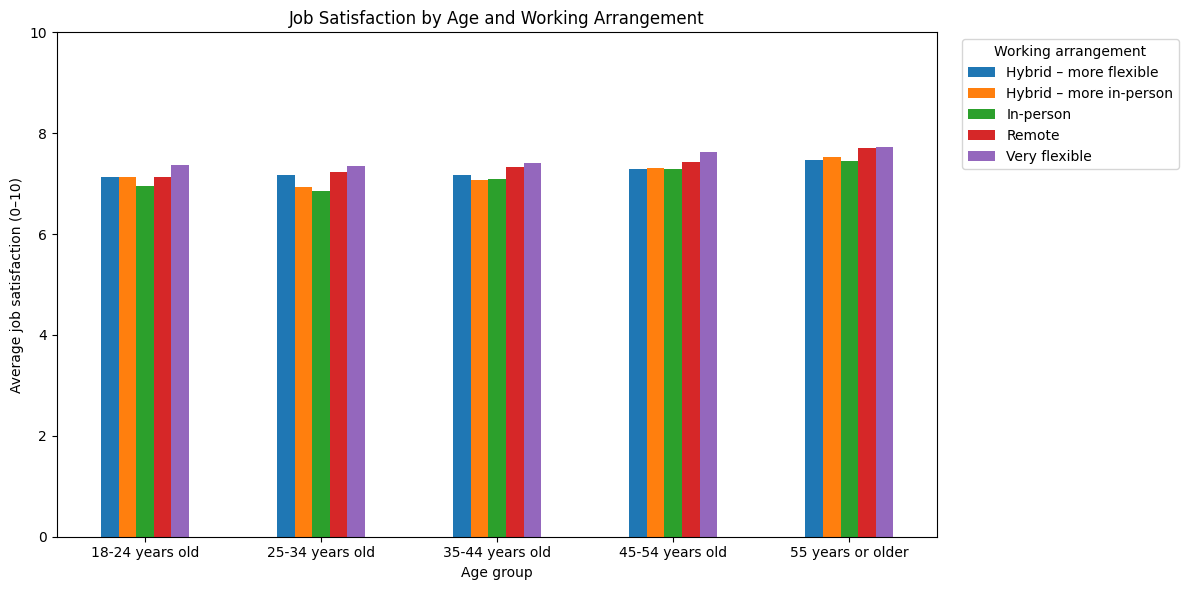

In [54]:
age_summary.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Job Satisfaction by Age and Working Arrangement")
plt.xlabel("Age group")
plt.ylabel("Average job satisfaction (0–10)")
plt.ylim(0, 10)
plt.xticks(rotation=0)

plt.legend(
    title="Working arrangement",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(
    "job_satisfaction_age.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Finding 3: Age and job satisfaction

Average job satisfaction generally increased slightly across the older age groups. Respondents aged 55 or older with very flexible working arrangements reported the highest average satisfaction (7.73). In-person respondents aged 25–34 reported the lowest average satisfaction (6.85). Although the differences were small, very flexible work was associated with the highest satisfaction in every age group.

# ***Work Flexibility and Job Satisfaction in Tech***

## ***Project overview***

This project explores whether working arrangements are associated with job satisfaction among respondents to the 2025 Stack Overflow Developer Survey. It also examines whether job-satisfaction patterns differ by work experience and age.

## ***Research questions***

1. Is working arrangement associated with developers’ job satisfaction?
2. Does the relationship change with years of work experience?
3. Does the relationship change across age groups?

## ***Dataset***

The project uses the [2025 Stack Overflow Developer Survey](https://survey.stackoverflow.co/). The dataset contains 49,191 responses. The main analysis uses 22,797 respondents who provided both a working-arrangement answer and a job-satisfaction score.


In [55]:
!ls -lh *.png

-rw-r--r-- 1 root root 151K Aug 19 08:04 job_satisfaction_age.png
-rw-r--r-- 1 root root 147K Aug 19 08:04 job_satisfaction_experience.png
-rw-r--r-- 1 root root 121K Aug 19 08:04 job_satisfaction_work_arrangement.png


In [56]:
!ls -lh job_satisfaction_age.png

-rw-r--r-- 1 root root 151K Aug 19 08:04 job_satisfaction_age.png


## Limitations

* The survey was voluntary, so the responses may not represent everyone working in technology.
* Many respondents did not answer the working-arrangement or job-satisfaction questions. The main analysis therefore used 22,797 of the 49,191 responses.
* Job satisfaction was self-reported therefore may be interpreted differently by each respondent.
* This analysis shows associations, not cause and effect. Other factors—such as salary, job role, country, and company culture—could influence satisfaction.
* The results show a relationship, but they cannot prove that flexibility causes greater satisfaction


***Conclusion***

Overall, more flexible working arrangements were associated with slightly higher job satisfaction among the survey respondents. Satisfaction also generally increased with age and years of work experience. However, the differences between the groups were small, suggesting that working arrangement is only one of several factors related to job satisfaction. These results do not prove cause and effect because satisfaction is self-reported and other factors—such as salary, job role, country, and company culture—were not investigated.